In [1]:
# ==========================================================
# Graph Neural Network (GCN)
# Antibody Binding Kinetics
# Google Colab
# ==========================================================

!pip install -q torch torchvision torchaudio

!pip install -q torch-geometric

!pip install -q scipy

!pip install -q matplotlib

!pip install -q pandas

!pip install -q tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.7 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from tqdm import tqdm

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

from torch_geometric.nn import GCNConv

print(torch.__version__)

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

2.11.0+cpu
cpu


In [3]:
# ==========================================================
# Physical Parameters
# ==========================================================

D = 1e-10

kf = 1e5

kr = 1e-2

cb_sat = 2.66e-8

c_bulk = 4.48-5

h = 5e-5

t0 = 0.0

tfinal = 500.0

In [4]:
# ==========================================================
# Hyperparameters
# ==========================================================

# Number of graph nodes sampled from the numerical solver
NUM_NODES = 100

# Number of features for each node:
# [z, t, c(z,t), cb(t)]
NODE_FEATURES = 4

# GNN Architecture
HIDDEN_DIM = 64
OUTPUT_DIM = 1

# Training
EPOCHS = 500
LEARNING_RATE = 1e-3
BATCH_SIZE = 8

In [5]:
# ==========================================================
# Create Node Features from Numerical Solver
# ==========================================================

import numpy as np
import torch
from google.colab import drive # Added import
drive.mount('/content/drive')

# ----------------------------------------------------------
# Path to numerical solver files
# ----------------------------------------------------------

DATA_PATH = "/content/drive/MyDrive/"   # <-- Change if needed

# ----------------------------------------------------------
# Load numerical solver results
# ----------------------------------------------------------

coordinates = np.load(DATA_PATH + "coordinates.npy")
concentration = np.load(DATA_PATH + "concentration.npy")
binding = np.load(DATA_PATH + "binding.npy")

# ----------------------------------------------------------
# Node Features
# ----------------------------------------------------------

z = coordinates[:, 0]
t = coordinates[:, 1]
c = concentration
cb = binding

node_features = np.column_stack((
    z,
    t,
    c,
    cb
))

x = torch.tensor(
    node_features,
    dtype=torch.float32
)

print("="*60)
print("Node Features Loaded")
print("="*60)
print("Number of Nodes :", x.shape[0])
print("Features/Node   :", x.shape[1])
print("="*60)

Mounted at /content/drive
Node Features Loaded
Number of Nodes : 420000
Features/Node   : 4


In [6]:
edge_list = []

for i in range(NUM_NODES-1):

    edge_list.append([i,i+1])

    edge_list.append([i+1,i])

edge_index = torch.tensor(

    edge_list,

    dtype=torch.long

).t().contiguous()

In [7]:
y = torch.tensor(
    concentration.reshape(-1,1),
    dtype=torch.float32
)

In [8]:
graph = Data(

    x=x,

    edge_index=edge_index,

    y=y

)

graph = graph.to(device)

print(graph)

Data(x=[420000, 4], edge_index=[2, 198], y=[420000, 1])


In [9]:
# ==========================================================
# Graph Convolution Network
# ==========================================================

class GCN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = GCNConv(

            NODE_FEATURES,

            HIDDEN_DIM

        )

        self.conv2 = GCNConv(

            HIDDEN_DIM,

            HIDDEN_DIM

        )

        self.conv3 = GCNConv(

            HIDDEN_DIM,

            OUTPUT_DIM

        )

    def forward(

        self,

        data

    ):

        x = data.x

        edge_index = data.edge_index

        x = self.conv1(

            x,

            edge_index

        )

        x = F.relu(x)

        x = self.conv2(

            x,

            edge_index

        )

        x = F.relu(x)

        x = self.conv3(

            x,

            edge_index

        )

        return x


model = GCN().to(device)

print(model)

GCN(
  (conv1): GCNConv(4, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 1)
)


In [10]:
# ==========================================================
# Step 8 : Loss Function and Optimizer
# ==========================================================

import torch.optim as optim

criterion = torch.nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-5
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=100,
    gamma=0.5
)

print("Optimizer Initialized")

Optimizer Initialized


In [11]:
# ==========================================================
# Step 9 : Training Function
# ==========================================================

def train():

    model.train()

    optimizer.zero_grad()

    prediction = model(graph)

    loss = criterion(
        prediction,
        graph.y
    )

    loss.backward()

    optimizer.step()

    scheduler.step()

    return loss.item()

In [12]:
# ==========================================================
# Step 10 : Training Loop
# ==========================================================

loss_history = []

print("Starting GNN Training...\n")

for epoch in range(EPOCHS):

    loss = train()

    loss_history.append(loss)

    if epoch % 20 == 0:

        print(
            f"Epoch {epoch:4d} | Loss = {loss:.6e}"
        )

print("\nTraining Completed")

Starting GNN Training...

Epoch    0 | Loss = 2.987951e+03
Epoch   20 | Loss = 8.704388e+01
Epoch   40 | Loss = 4.430234e+00
Epoch   60 | Loss = 3.335943e-01
Epoch   80 | Loss = 7.785915e-03
Epoch  100 | Loss = 9.106196e-04
Epoch  120 | Loss = 2.858793e-04
Epoch  140 | Loss = 2.633139e-04
Epoch  160 | Loss = 1.026349e-03
Epoch  180 | Loss = 2.576038e-04
Epoch  200 | Loss = 2.178163e-04
Epoch  220 | Loss = 2.039402e-04
Epoch  240 | Loss = 1.946881e-04
Epoch  260 | Loss = 1.853363e-04
Epoch  280 | Loss = 1.741431e-04
Epoch  300 | Loss = 1.320735e-04
Epoch  320 | Loss = 1.806647e-05
Epoch  340 | Loss = 7.971450e-06
Epoch  360 | Loss = 5.135442e-05
Epoch  380 | Loss = 6.283942e-06
Epoch  400 | Loss = 2.526218e-06
Epoch  420 | Loss = 2.004070e-06
Epoch  440 | Loss = 1.603241e-06
Epoch  460 | Loss = 1.291271e-06
Epoch  480 | Loss = 1.049740e-06

Training Completed


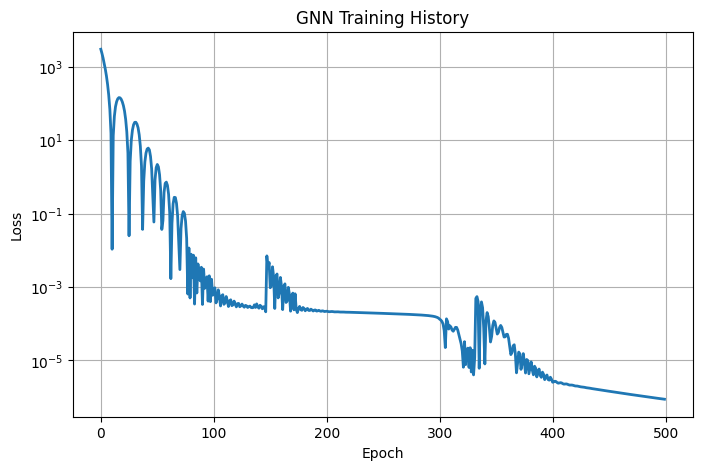

In [13]:
# ==========================================================
# Step 11 : Plot Loss History
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    loss_history,
    linewidth=2
)

plt.yscale("log")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("GNN Training History")

plt.grid(True)

plt.show()

In [14]:
# ==========================================================
# Step 12 : Prediction
# ==========================================================

model.eval()

with torch.no_grad():

    prediction = model(graph)

prediction = prediction.cpu().numpy()

ground_truth = graph.y.cpu().numpy()

print("Prediction Shape:", prediction.shape)
print("Ground Truth Shape:", ground_truth.shape)

Prediction Shape: (420000, 1)
Ground Truth Shape: (420000, 1)


In [16]:
# ==========================================================
# Step 13 : Evaluation
# ==========================================================

from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(
    ground_truth,
    prediction
)

mae = mean_absolute_error(
    ground_truth,
    prediction
)

relative_error = (
    np.linalg.norm(prediction - ground_truth)
    /
    np.linalg.norm(ground_truth)
)

print("="*60)
print("Graph Neural Network Evaluation")
print("="*60)

print(f"MSE            : {mse:.6e}")
print(f"MAE            : {mae:.6e}")
print(f"Relative Error : {relative_error:.6e}")

print("="*60)

Graph Neural Network Evaluation
MSE            : 8.636451e-07
MAE            : 6.539276e-04
Relative Error : 2.714576e+01


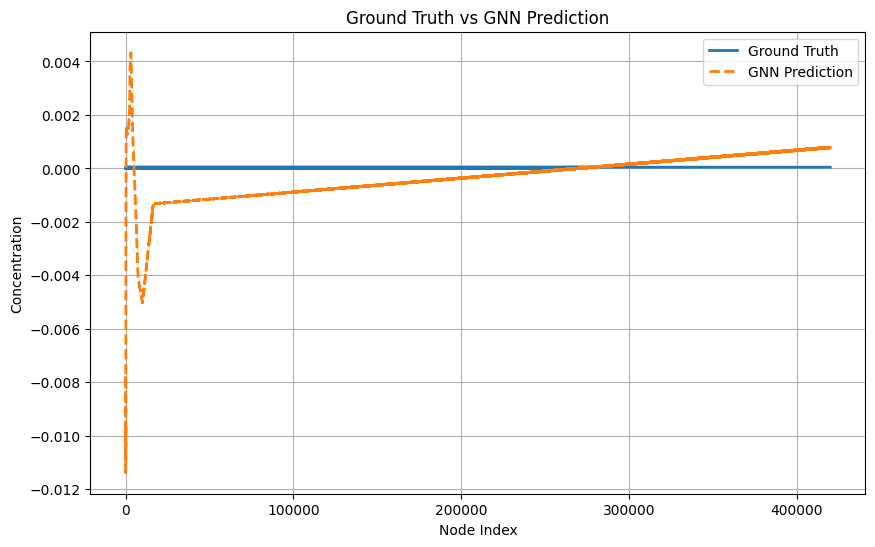

In [17]:
# ==========================================================
# Step 14 : Visualization
# ==========================================================

plt.figure(figsize=(10,6))

plt.plot(
    ground_truth,
    label="Ground Truth",
    linewidth=2
)

plt.plot(
    prediction,
    '--',
    label="GNN Prediction",
    linewidth=2
)

plt.xlabel("Node Index")

plt.ylabel("Concentration")

plt.title("Ground Truth vs GNN Prediction")

plt.legend()

plt.grid(True)

plt.show()

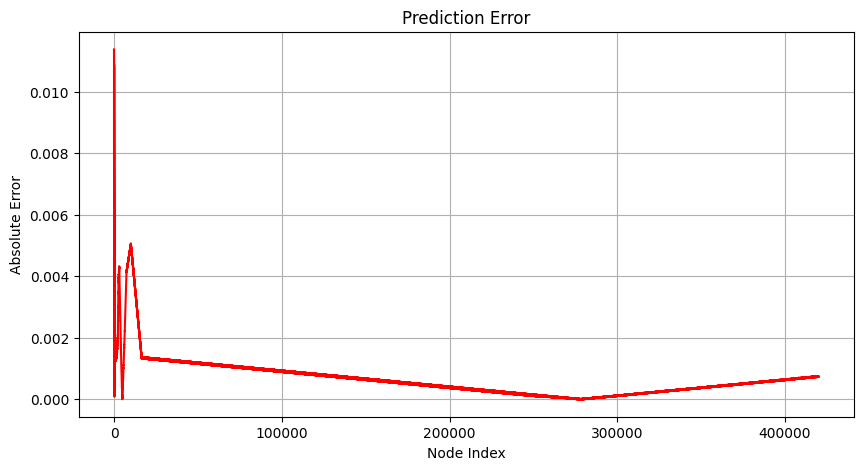

In [18]:
# ==========================================================
# Absolute Error
# ==========================================================

error = np.abs(
    prediction-ground_truth
)

plt.figure(figsize=(10,5))

plt.plot(
    error,
    color='red'
)

plt.xlabel("Node Index")

plt.ylabel("Absolute Error")

plt.title("Prediction Error")

plt.grid(True)

plt.show()

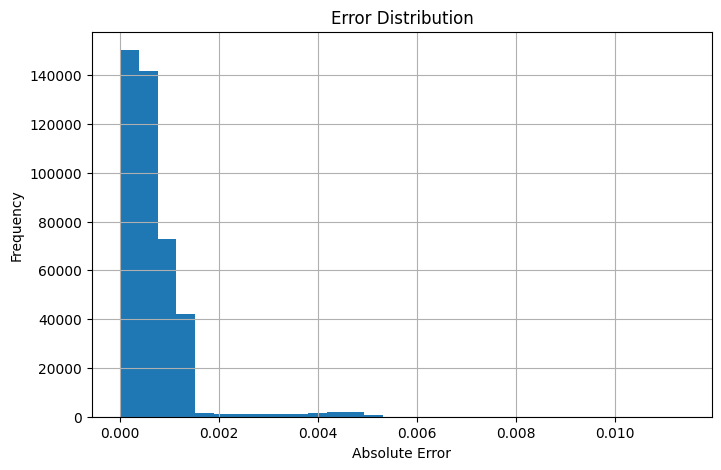

In [19]:
plt.figure(figsize=(8,5))

plt.hist(
    error,
    bins=30
)

plt.xlabel("Absolute Error")

plt.ylabel("Frequency")

plt.title("Error Distribution")

plt.grid(True)

plt.show()

In [20]:
# ==========================================================
# Step 15 : Save Model
# ==========================================================

torch.save(

    model.state_dict(),

    "GNN_Antibody_Model.pth"

)

print("Model Saved Successfully")

Model Saved Successfully


In [21]:
loaded_model = GCN().to(device)

loaded_model.load_state_dict(

    torch.load(

        "GNN_Antibody_Model.pth",

        map_location=device

    )

)

loaded_model.eval()

print("Model Loaded Successfully")

Model Loaded Successfully


In [22]:
# ==========================================================
# Step 16 : Save Results
# ==========================================================

import pandas as pd

history = pd.DataFrame({

    "Training Loss":loss_history

})

history.to_csv(

    "GNN_Training_History.csv",

    index=False

)

In [23]:
results = pd.DataFrame({

    "Ground Truth":ground_truth.flatten(),

    "Prediction":prediction.flatten(),

    "Absolute Error":error.flatten()

})

results.to_csv(

    "GNN_Predictions.csv",

    index=False

)

print("Results Saved Successfully")

Results Saved Successfully


In [25]:
# ==========================================================
# Step 17 : Final Report
# ==========================================================

print("="*70)
print("          GRAPH NEURAL NETWORK FINAL REPORT")
print("="*70)

print("\nModel Information")
print("-"*70)

print("Architecture        : Graph Convolutional Network (GCN)")
print(f"Device              : {device}")
print("Training Dataset    : Numerical Solver Output")
print(f"Number of Nodes     : {NUM_NODES}")
print(f"Node Features       : {NODE_FEATURES}")
print(f"Hidden Dimension    : {HIDDEN_DIM}")

print("\nNode Features")
print("-"*70)
print("Feature 1           : Spatial Coordinate (z)")
print("Feature 2           : Time (t)")
print("Feature 3           : Concentration c(z,t)")
print("Feature 4           : Bound Concentration cb(t)")

print("\nTraining")
print("-"*70)

print(f"Epochs              : {EPOCHS}")
print(f"Learning Rate       : {LEARNING_RATE}")
print(f"Batch Size          : {BATCH_SIZE}")

print("\nPerformance")
print("-"*70)

print(f"Final Training Loss : {loss_history[-1]:.6e}")
print(f"MSE                 : {mse:.6e}")
print(f"MAE                 : {mae:.6e}")
print(f"Relative Error      : {relative_error:.6e}")

print("\nGenerated Files")
print("-"*70)

print("✓ GNN_Antibody_Model.pth")
print("✓ GNN_Training_History.csv")
print("✓ GNN_Predictions.csv")

print("="*70)
print("GRAPH NEURAL NETWORK COMPLETED SUCCESSFULLY")
print("="*70)

          GRAPH NEURAL NETWORK FINAL REPORT

Model Information
----------------------------------------------------------------------
Architecture        : Graph Convolutional Network (GCN)
Device              : cpu
Training Dataset    : Numerical Solver Output
Number of Nodes     : 100
Node Features       : 4
Hidden Dimension    : 64

Node Features
----------------------------------------------------------------------
Feature 1           : Spatial Coordinate (z)
Feature 2           : Time (t)
Feature 3           : Concentration c(z,t)
Feature 4           : Bound Concentration cb(t)

Training
----------------------------------------------------------------------
Epochs              : 500
Learning Rate       : 0.001
Batch Size          : 8

Performance
----------------------------------------------------------------------
Final Training Loss : 8.721552e-07
MSE                 : 8.636451e-07
MAE                 : 6.539276e-04
Relative Error      : 2.714576e+01

Generated Files
----------